# 02 - MLP Baseline Fase 1

**Proyecto:** Predicción de inundaciones en Antioquia (Fase 1)

**Objetivo:** entrenar y evaluar un baseline de clasificación binaria `flood_next_24h` con:
1. Regresión logística (baseline lineal).
2. Red neuronal superficial (`MLPClassifier`).

**Alcance:** solo enfoque tabular municipio-fecha, sin LSTM y sin geoprocesamiento pesado.

## 1. Configuración e imports

In [1]:
import os
import json
import random
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
plt.style.use("default")

print("Entorno listo.")

Entorno listo.


In [2]:
# Ruta principal esperada en Colab
DATA_PATH = "/content/phase1_dataset_municipio_fecha.csv"

candidate_paths = [
    DATA_PATH,
    "phase1_dataset_municipio_fecha.csv",
    "./phase1_dataset_municipio_fecha.csv",
    "processed/fase1/phase1_dataset_municipio_fecha.csv",
    "../processed/fase1/phase1_dataset_municipio_fecha.csv",
    "/content/processed/fase1/phase1_dataset_municipio_fecha.csv",
    "/content/drive/MyDrive/phase1_dataset_municipio_fecha.csv",
]

data_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError(
        "No se encontr? 'phase1_dataset_municipio_fecha.csv'. "
        "Sube el archivo a /content o ajusta DATA_PATH."
    )

df = pd.read_csv(data_path)
print(f"Dataset cargado desde: {data_path}")


Dataset cargado desde: ../processed/fase1/phase1_dataset_municipio_fecha.csv


## 2. Revisión inicial del dataset

Shape: (341787, 52)

Tipos de columnas:
municipio_key                                  str
date                                datetime64[us]
municipio_name                                 str
stations_in_municipio                      float64
latitud_raw                                float64
longitud_raw                               float64
altitud_raw                                float64
meteo_obs_count_24h                        float64
meteo_station_count_24h                    float64
meteo_temp_mean_24h                        float64
meteo_temp_max_24h                         float64
meteo_rh_mean_24h                          float64
meteo_rh_max_24h                           float64
meteo_wind_mean_24h                        float64
meteo_wind_max_24h                         float64
precip_mm_24h_sum                          float64
precip_mm_24h_max                          float64
precip_obs_count_24h                       float64
precip_station_count_24h                  

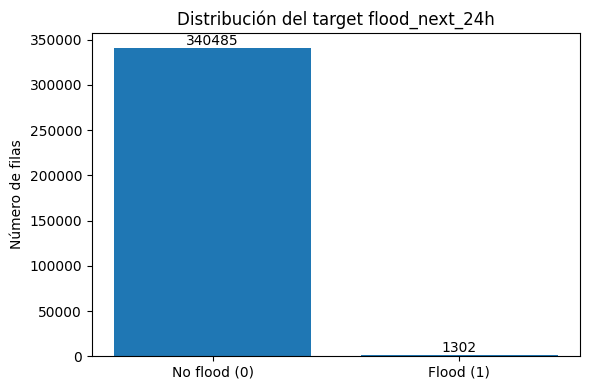

In [3]:
TARGET_COL = "flood_next_24h"
if TARGET_COL not in df.columns:
    raise ValueError(f"No existe la columna objetivo requerida: {TARGET_COL}")

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Shape:", df.shape)
print("\nTipos de columnas:")
print(df.dtypes)

null_counts = df.isna().sum().sort_values(ascending=False)
print("\nNulos por columna (top 25):")
print(null_counts.head(25))

y_tmp = pd.to_numeric(df[TARGET_COL], errors="coerce").fillna(0).astype(int)
target_counts = y_tmp.value_counts().sort_index()
positive_rate = float(y_tmp.mean())

print("\nDistribución target flood_next_24h:")
print(target_counts)
print(f"Tasa positiva: {positive_rate:.4f} ({positive_rate*100:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["No flood (0)", "Flood (1)"], [target_counts.get(0, 0), target_counts.get(1, 0)])
ax.set_title("Distribución del target flood_next_24h")
ax.set_ylabel("Número de filas")
for i, v in enumerate([target_counts.get(0, 0), target_counts.get(1, 0)]):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 3. Selección de variables predictoras

Se excluyen columnas no aptas para modelado directo:
- `municipio_key`
- `municipio_name`
- `date`
- `flood_next_24h` (objetivo)

In [4]:
EXCLUDE_COLS = {"municipio_key", "municipio_name", "date", TARGET_COL}

numeric_feature_cols = [
    c for c in df.columns
    if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(df[c])
]

# Eliminar columnas numéricas degeneradas (todo nulo o varianza 0)
usable_feature_cols = []
for c in numeric_feature_cols:
    non_null = df[c].notna().sum()
    nunique = df[c].nunique(dropna=True)
    if non_null > 0 and nunique > 1:
        usable_feature_cols.append(c)

if len(usable_feature_cols) == 0:
    raise ValueError("No se detectaron variables numéricas utilizables para entrenamiento.")

print(f"Total de features numéricas detectadas: {len(usable_feature_cols)}")
print("Features seleccionadas:")
for c in usable_feature_cols:
    print("-", c)

Total de features numéricas detectadas: 41
Features seleccionadas:
- stations_in_municipio
- latitud_raw
- longitud_raw
- altitud_raw
- meteo_obs_count_24h
- meteo_station_count_24h
- meteo_temp_mean_24h
- meteo_temp_max_24h
- meteo_rh_mean_24h
- meteo_rh_max_24h
- meteo_wind_mean_24h
- meteo_wind_max_24h
- precip_mm_24h_sum
- precip_mm_24h_max
- precip_obs_count_24h
- precip_mm_48h_sum
- precip_mm_72h_sum
- year
- month
- day
- day_of_year
- day_of_week
- is_weekend
- stations_in_municipio_missing
- latitud_raw_missing
- longitud_raw_missing
- altitud_raw_missing
- meteo_obs_count_24h_missing
- meteo_station_count_24h_missing
- meteo_temp_mean_24h_missing
- meteo_temp_max_24h_missing
- meteo_rh_mean_24h_missing
- meteo_rh_max_24h_missing
- meteo_wind_mean_24h_missing
- meteo_wind_max_24h_missing
- precip_mm_24h_sum_missing
- precip_mm_24h_max_missing
- precip_obs_count_24h_missing
- precip_station_count_24h_missing
- precip_mm_48h_sum_missing
- precip_mm_72h_sum_missing


## 4. Split temporal (70% train, 15% validation, 15% test)

El split se realiza por fecha ordenada, no aleatorio.

In [5]:
if "date" not in df.columns:
    raise ValueError("La columna 'date' es obligatoria para split temporal.")

work = df.copy()
work["date"] = pd.to_datetime(work["date"], errors="coerce")
work = work.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
work[TARGET_COL] = pd.to_numeric(work[TARGET_COL], errors="coerce").fillna(0).astype(int)

unique_dates = np.array(sorted(work["date"].dt.normalize().unique()))
n_dates = len(unique_dates)
if n_dates < 10:
    raise ValueError(f"Muy pocas fechas ({n_dates}) para split temporal robusto.")

train_end = int(np.floor(n_dates * 0.70))
val_end = int(np.floor(n_dates * 0.85))
train_end = max(1, train_end)
val_end = max(train_end + 1, val_end)
val_end = min(val_end, n_dates - 1)

train_dates = unique_dates[:train_end]
val_dates = unique_dates[train_end:val_end]
test_dates = unique_dates[val_end:]

if len(val_dates) == 0 or len(test_dates) == 0:
    raise ValueError("No fue posible construir validation/test con el split temporal 70/15/15.")

train_mask = work["date"].dt.normalize().isin(train_dates)
val_mask = work["date"].dt.normalize().isin(val_dates)
test_mask = work["date"].dt.normalize().isin(test_dates)

X_train_raw = work.loc[train_mask, usable_feature_cols].copy()
X_val_raw = work.loc[val_mask, usable_feature_cols].copy()
X_test_raw = work.loc[test_mask, usable_feature_cols].copy()

y_train = work.loc[train_mask, TARGET_COL].astype(int).to_numpy()
y_val = work.loc[val_mask, TARGET_COL].astype(int).to_numpy()
y_test = work.loc[test_mask, TARGET_COL].astype(int).to_numpy()

print(f"N fechas: {n_dates}")
print(f"Train fechas: {len(train_dates)} | {pd.to_datetime(train_dates[0]).date()} -> {pd.to_datetime(train_dates[-1]).date()}")
print(f"Val fechas:   {len(val_dates)} | {pd.to_datetime(val_dates[0]).date()} -> {pd.to_datetime(val_dates[-1]).date()}")
print(f"Test fechas:  {len(test_dates)} | {pd.to_datetime(test_dates[0]).date()} -> {pd.to_datetime(test_dates[-1]).date()}")

print("\nTamaños de split (filas):")
print("Train:", X_train_raw.shape)
print("Val:  ", X_val_raw.shape)
print("Test: ", X_test_raw.shape)

print("\nTasa positiva por split:")
print(f"Train: {y_train.mean():.4f}")
print(f"Val:   {y_val.mean():.4f}")
print(f"Test:  {y_test.mean():.4f}")

N fechas: 2557
Train fechas: 1789 | 2018-01-01 -> 2022-11-24
Val fechas:   384 | 2022-11-25 -> 2023-12-13
Test fechas:  384 | 2023-12-14 -> 2024-12-31

Tamaños de split (filas):
Train: (239032, 41)
Val:   (51240, 41)
Test:  (51515, 41)

Tasa positiva por split:
Train: 0.0042
Val:   0.0022
Test:  0.0038


## 5. Imputación, escalamiento y utilidades de evaluación

In [6]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_raw)
X_val_imp = imputer.transform(X_val_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imp)
X_val = scaler.transform(X_val_imp)
X_test = scaler.transform(X_test_imp)

def compute_metrics(y_true, y_pred, y_prob):
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "support": int(len(y_true)),
    }
    if len(np.unique(y_true)) > 1:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    else:
        metrics["roc_auc"] = float("nan")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    metrics["confusion_matrix"] = cm.tolist()
    return metrics

def predict_with_proba(model, X):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return y_pred, y_prob

def plot_diagnostics(y_true, y_pred, y_prob, title_prefix):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # Matriz de confusión
    ax = axes[0]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{title_prefix}\nMatriz de confusión")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Histograma de probabilidades
    ax = axes[1]
    ax.hist(y_prob[y_true == 0], bins=30, alpha=0.65, label="Clase real 0")
    ax.hist(y_prob[y_true == 1], bins=30, alpha=0.65, label="Clase real 1")
    ax.set_title(f"{title_prefix}\nHistograma de probabilidades")
    ax.set_xlabel("Probabilidad predicha de clase 1")
    ax.set_ylabel("Frecuencia")
    ax.legend()

    # Curva ROC
    ax = axes[2]
    if len(np.unique(y_true)) > 1:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        ax.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}")
        ax.plot([0, 1], [0, 1], linestyle="--")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc="lower right")
    else:
        ax.text(0.1, 0.5, "ROC no disponible\n(solo una clase en y_true)")
    ax.set_title(f"{title_prefix}\nCurva ROC")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")

    plt.tight_layout()
    plt.show()

def random_oversample_binary(X, y, random_state=42):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y)
    classes, counts = np.unique(y, return_counts=True)
    if len(classes) < 2:
        return X, y, False

    maj_class = classes[np.argmax(counts)]
    min_class = classes[np.argmin(counts)]
    n_maj = counts[np.argmax(counts)]
    n_min = counts[np.argmin(counts)]
    if n_min == 0 or n_min == n_maj:
        return X, y, False

    idx_maj = np.where(y == maj_class)[0]
    idx_min = np.where(y == min_class)[0]
    extra = rng.choice(idx_min, size=(n_maj - n_min), replace=True)
    idx_new = np.concatenate([idx_maj, idx_min, extra])
    rng.shuffle(idx_new)
    return X[idx_new], y[idx_new], True

print("Transformaciones listas.")

Transformaciones listas.


## 6. Baseline 1: Regresión logística

Métricas - Logistic Regression
train      | acc=0.6773 prec=0.0093 rec=0.7279 f1=0.0184 auc=0.7663
validation | acc=0.2705 prec=0.0026 rec=0.8919 f1=0.0053 auc=0.6456
test       | acc=0.1869 prec=0.0044 rec=0.9538 f1=0.0088 auc=0.6935

Classification report (validation):
              precision    recall  f1-score   support

           0     0.9991    0.2691    0.4240     51129
           1     0.0026    0.8919    0.0053       111

    accuracy                         0.2705     51240
   macro avg     0.5009    0.5805    0.2146     51240
weighted avg     0.9970    0.2705    0.4231     51240

Classification report (test):
              precision    recall  f1-score   support

           0     0.9990    0.1840    0.3107     51320
           1     0.0044    0.9538    0.0088       195

    accuracy                         0.1869     51515
   macro avg     0.5017    0.5689    0.1598     51515
weighted avg     0.9953    0.1869    0.3096     51515



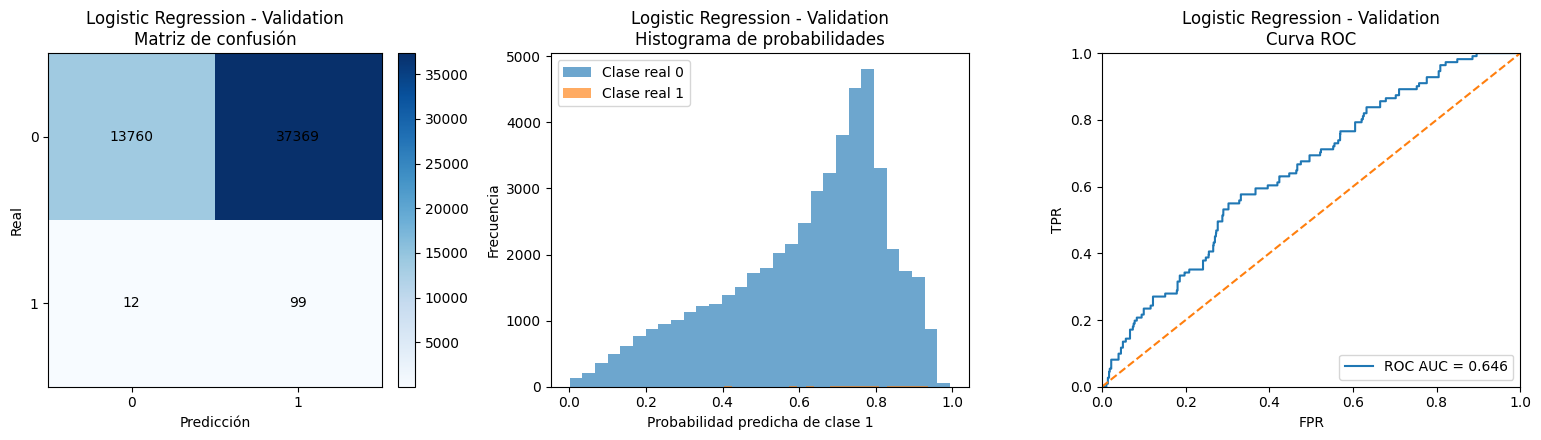

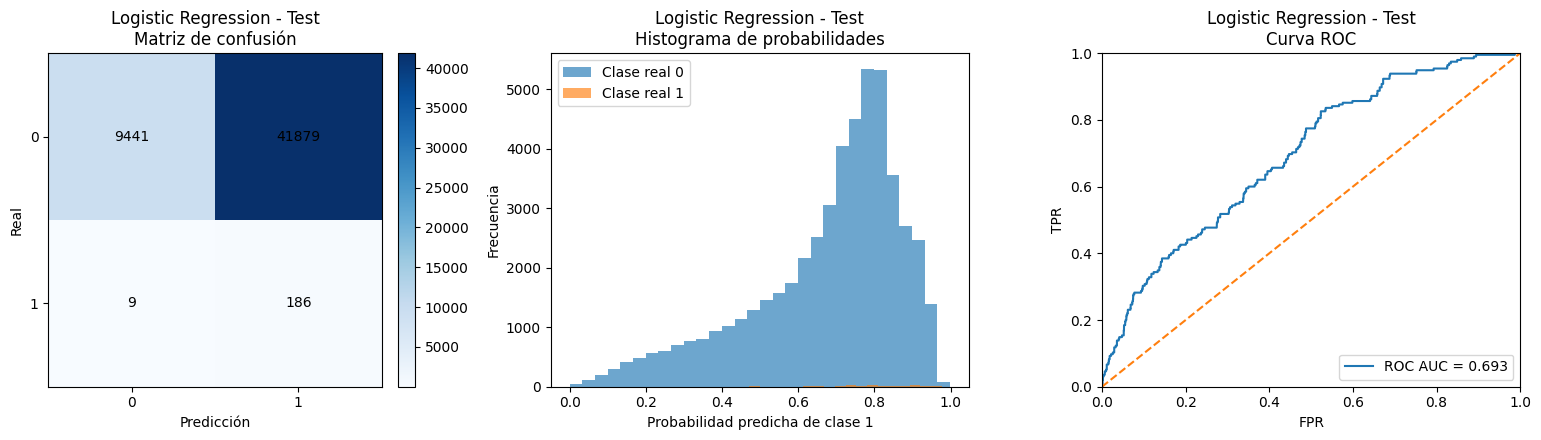

In [7]:
train_pos_rate = float(y_train.mean())
use_balanced = train_pos_rate < 0.40
class_weight = "balanced" if use_balanced else None

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight=class_weight,
    random_state=SEED,
    solver="lbfgs",
)
log_reg.fit(X_train, y_train)

results = {
    "logistic_regression": {
        "class_weight": class_weight,
    },
    "mlp": {}
}

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("validation", X_val, y_val),
    ("test", X_test, y_test),
]:
    y_pred, y_prob = predict_with_proba(log_reg, X_split)
    results["logistic_regression"][split_name] = compute_metrics(y_split, y_pred, y_prob)

print("Métricas - Logistic Regression")
for split_name in ["train", "validation", "test"]:
    m = results["logistic_regression"][split_name]
    print(
        f"{split_name:10s} | acc={m['accuracy']:.4f} "
        f"prec={m['precision']:.4f} rec={m['recall']:.4f} "
        f"f1={m['f1']:.4f} auc={m['roc_auc']:.4f}"
    )

print("\nClassification report (validation):")
y_val_pred_lr, y_val_prob_lr = predict_with_proba(log_reg, X_val)
print(classification_report(y_val, y_val_pred_lr, digits=4, zero_division=0))

print("Classification report (test):")
y_test_pred_lr, y_test_prob_lr = predict_with_proba(log_reg, X_test)
print(classification_report(y_test, y_test_pred_lr, digits=4, zero_division=0))

plot_diagnostics(y_val, y_val_pred_lr, y_val_prob_lr, "Logistic Regression - Validation")
plot_diagnostics(y_test, y_test_pred_lr, y_test_prob_lr, "Logistic Regression - Test")

## 7. Baseline 2: MLPClassifier (red neuronal superficial)

Estrategia ante desbalance en train:
- si la tasa positiva de train es baja (`< 0.40`), se aplica sobre-muestreo aleatorio simple solo en train.
- validation y test permanecen intactos.

Métricas - MLPClassifier
train      | acc=0.9859 prec=0.2276 rec=0.9980 f1=0.3707 auc=0.9967
validation | acc=0.9664 prec=0.0031 rec=0.0450 f1=0.0058 auc=0.5726
test       | acc=0.9715 prec=0.0016 rec=0.0103 f1=0.0027 auc=0.5693

Classification report (validation):
              precision    recall  f1-score   support

           0     0.9979    0.9684    0.9829     51129
           1     0.0031    0.0450    0.0058       111

    accuracy                         0.9664     51240
   macro avg     0.5005    0.5067    0.4943     51240
weighted avg     0.9957    0.9664    0.9808     51240

Classification report (test):
              precision    recall  f1-score   support

           0     0.9962    0.9752    0.9856     51320
           1     0.0016    0.0103    0.0027       195

    accuracy                         0.9715     51515
   macro avg     0.4989    0.4927    0.4941     51515
weighted avg     0.9924    0.9715    0.9818     51515



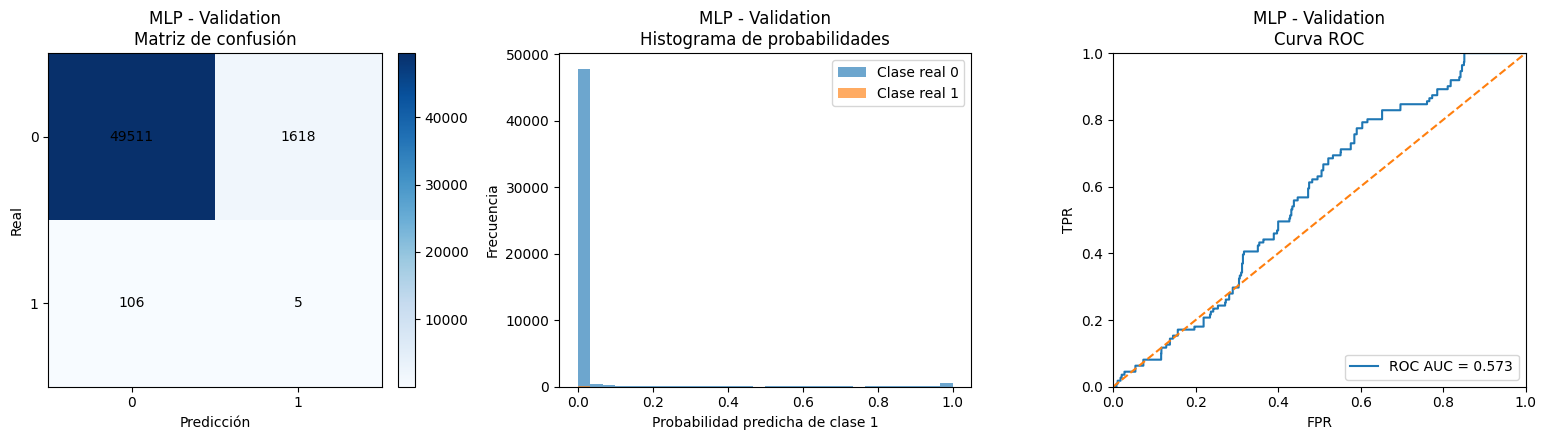

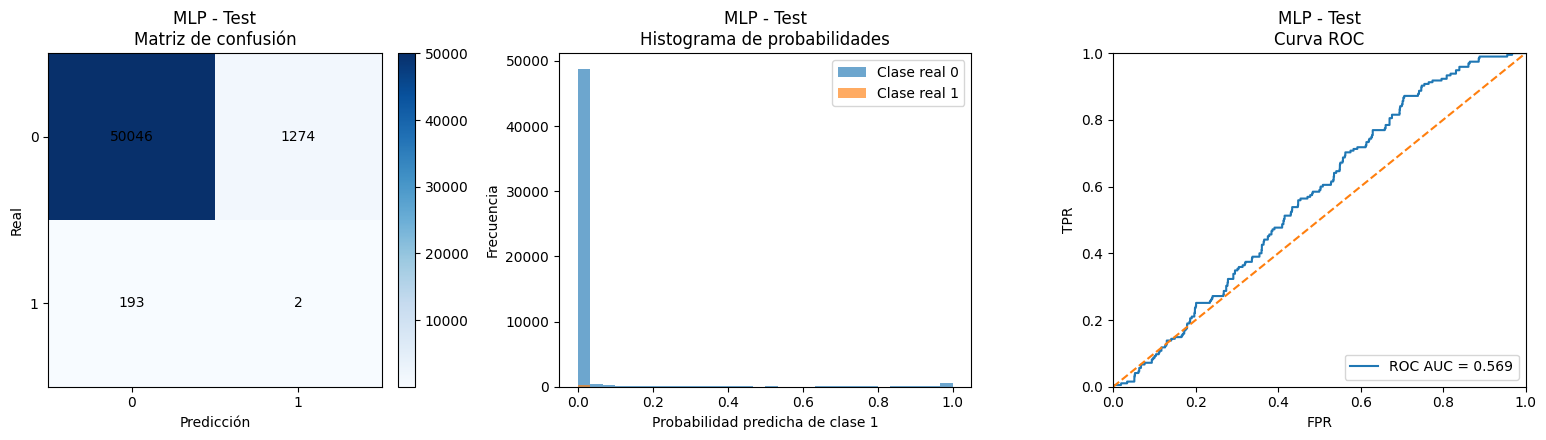

In [8]:
oversampling_used = False
if train_pos_rate < 0.40:
    X_train_mlp, y_train_mlp, oversampling_used = random_oversample_binary(
        X_train, y_train, random_state=SEED
    )
else:
    X_train_mlp, y_train_mlp = X_train, y_train

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=SEED,
)
mlp.fit(X_train_mlp, y_train_mlp)

results["mlp"]["oversampling_used"] = bool(oversampling_used)
results["mlp"]["train_size_after_sampling"] = int(len(y_train_mlp))

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("validation", X_val, y_val),
    ("test", X_test, y_test),
]:
    y_pred, y_prob = predict_with_proba(mlp, X_split)
    results["mlp"][split_name] = compute_metrics(y_split, y_pred, y_prob)

print("Métricas - MLPClassifier")
for split_name in ["train", "validation", "test"]:
    m = results["mlp"][split_name]
    print(
        f"{split_name:10s} | acc={m['accuracy']:.4f} "
        f"prec={m['precision']:.4f} rec={m['recall']:.4f} "
        f"f1={m['f1']:.4f} auc={m['roc_auc']:.4f}"
    )

print("\nClassification report (validation):")
y_val_pred_mlp, y_val_prob_mlp = predict_with_proba(mlp, X_val)
print(classification_report(y_val, y_val_pred_mlp, digits=4, zero_division=0))

print("Classification report (test):")
y_test_pred_mlp, y_test_prob_mlp = predict_with_proba(mlp, X_test)
print(classification_report(y_test, y_test_pred_mlp, digits=4, zero_division=0))

plot_diagnostics(y_val, y_val_pred_mlp, y_val_prob_mlp, "MLP - Validation")
plot_diagnostics(y_test, y_test_pred_mlp, y_test_prob_mlp, "MLP - Test")

## 8. Comparación de métricas (validation y test)

In [9]:
rows = []
for model_name in ["logistic_regression", "mlp"]:
    for split_name in ["validation", "test"]:
        m = results[model_name][split_name]
        rows.append(
            {
                "model": model_name,
                "split": split_name,
                "accuracy": m["accuracy"],
                "precision": m["precision"],
                "recall": m["recall"],
                "f1": m["f1"],
                "roc_auc": m["roc_auc"],
            }
        )

comparison_df = pd.DataFrame(rows)
display(comparison_df)

best_val = comparison_df[comparison_df["split"] == "validation"].sort_values("f1", ascending=False).head(1)
print("Mejor modelo en validation (por F1):")
display(best_val)

,model,split,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,validation,0.270472,0.002642,0.891892,0.005269,0.645638
1,logistic_regression,test,0.186878,0.004422,0.953846,0.008803,0.693458
2,mlp,validation,0.966354,0.003081,0.045045,0.005767,0.572611
3,mlp,test,0.971523,0.001567,0.010256,0.002719,0.569319


Mejor modelo en validation (por F1):


,model,split,accuracy,precision,recall,f1,roc_auc
2,mlp,validation,0.966354,0.003081,0.045045,0.005767,0.572611


## 9. Guardado de artefactos y métricas

In [10]:
ARTIFACT_DIR = "models/fase1_mlp"
if not os.path.exists(ARTIFACT_DIR):
    alt = "../models/fase1_mlp"
    ARTIFACT_DIR = alt if os.path.exists(os.path.dirname(alt)) else ARTIFACT_DIR
os.makedirs(ARTIFACT_DIR, exist_ok=True)

baseline_model_path = os.path.join(ARTIFACT_DIR, "baseline_logistic_regression.joblib")
mlp_model_path = os.path.join(ARTIFACT_DIR, "mlp_classifier_phase1.joblib")
scaler_path = os.path.join(ARTIFACT_DIR, "standard_scaler.joblib")
imputer_path = os.path.join(ARTIFACT_DIR, "median_imputer.joblib")
metrics_path = os.path.join(ARTIFACT_DIR, "phase1_metrics.json")

joblib.dump(log_reg, baseline_model_path)
joblib.dump(mlp, mlp_model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(imputer, imputer_path)

payload = {
    "timestamp": datetime.utcnow().isoformat() + "Z",
    "dataset_path": data_path,
    "dataset_shape": [int(df.shape[0]), int(df.shape[1])],
    "target_positive_rate": float(positive_rate),
    "excluded_columns": sorted(list(EXCLUDE_COLS)),
    "usable_feature_columns": usable_feature_cols,
    "n_features": int(len(usable_feature_cols)),
    "split": {
        "train_dates": [str(pd.to_datetime(train_dates[0]).date()), str(pd.to_datetime(train_dates[-1]).date())],
        "validation_dates": [str(pd.to_datetime(val_dates[0]).date()), str(pd.to_datetime(val_dates[-1]).date())],
        "test_dates": [str(pd.to_datetime(test_dates[0]).date()), str(pd.to_datetime(test_dates[-1]).date())],
        "train_rows": int(len(y_train)),
        "validation_rows": int(len(y_val)),
        "test_rows": int(len(y_test)),
    },
    "models": results,
    "artifacts": {
        "baseline_model": baseline_model_path,
        "mlp_model": mlp_model_path,
        "scaler": scaler_path,
        "imputer": imputer_path,
    },
}

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

print("Artefactos guardados:")
print("-", baseline_model_path)
print("-", mlp_model_path)
print("-", scaler_path)
print("-", imputer_path)
print("-", metrics_path)


Artefactos guardados:
- ../models/fase1_mlp\baseline_logistic_regression.joblib
- ../models/fase1_mlp\mlp_classifier_phase1.joblib
- ../models/fase1_mlp\standard_scaler.joblib
- ../models/fase1_mlp\median_imputer.joblib
- ../models/fase1_mlp\phase1_metrics.json


C:\Users\Pc\AppData\Local\Temp\ipykernel_36112\1535446327.py:19: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat() + "Z",


## 10. Interpretación breve

La celda siguiente genera una interpretación automática y concisa sobre:
- desbalance del dataset,
- señales de subajuste/sobreajuste,
- compromiso precision vs recall.

In [11]:
def fit_diagnosis(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.10:
        return "Posible sobreajuste (brecha train-val alta en F1)."
    if val_f1 < 0.35 and train_f1 < 0.35:
        return "Posible subajuste (desempeño bajo tanto en train como en validation)."
    return "Generalización razonable para baseline inicial."

def precision_recall_comment(precision, recall):
    if recall + 0.08 < precision:
        return "Recall más problemático que precision (se escapan eventos positivos)."
    if precision + 0.08 < recall:
        return "Precision más problemática que recall (más falsos positivos)."
    return "Balance precision-recall aceptable para baseline." 

lr_val = results["logistic_regression"]["validation"]
mlp_val = results["mlp"]["validation"]

imbalance_text = (
    "alto" if positive_rate < 0.10 else
    "moderado" if positive_rate < 0.30 else
    "bajo"
)

md_text = f"""
### Interpretación breve automática
- **Desbalance:** tasa positiva global = **{positive_rate:.4f}** ({positive_rate*100:.2f}%), desbalance **{imbalance_text}**.
- **Regresión logística (validation):** F1 = **{lr_val['f1']:.4f}**, ROC-AUC = **{lr_val['roc_auc']:.4f}**. {fit_diagnosis(results['logistic_regression']['train']['f1'], lr_val['f1'])}
- **MLP (validation):** F1 = **{mlp_val['f1']:.4f}**, ROC-AUC = **{mlp_val['roc_auc']:.4f}**. {fit_diagnosis(results['mlp']['train']['f1'], mlp_val['f1'])}
- **Precision vs Recall (MLP validation):** precision = **{mlp_val['precision']:.4f}**, recall = **{mlp_val['recall']:.4f}**. {precision_recall_comment(mlp_val['precision'], mlp_val['recall'])}
"""

display(Markdown(md_text))


### Interpretación breve automática
- **Desbalance:** tasa positiva global = **0.0038** (0.38%), desbalance **alto**.
- **Regresión logística (validation):** F1 = **0.0053**, ROC-AUC = **0.6456**. Posible subajuste (desempeño bajo tanto en train como en validation).
- **MLP (validation):** F1 = **0.0058**, ROC-AUC = **0.5726**. Posible sobreajuste (brecha train-val alta en F1).
- **Precision vs Recall (MLP validation):** precision = **0.0031**, recall = **0.0450**. Balance precision-recall aceptable para baseline.


## Hallazgos preliminares

1. El split temporal permite evaluar desempeño en condiciones más realistas que un split aleatorio.
2. El baseline lineal (regresión logística) sirve como referencia mínima defendible para comparar el MLP.
3. El desbalance de clases condiciona la estabilidad de `precision`, `recall` y `f1`, por lo que el análisis no debe limitarse a `accuracy`.
4. La curva ROC y los histogramas de probabilidad ayudan a verificar separación de clases y calibración preliminar del modelo.

## Trabajo futuro inmediato

1. Ajustar hiperparámetros del MLP (tamaño de capas, `alpha`, `learning_rate_init`, `max_iter`) con validación temporal.
2. Explorar umbrales de decisión distintos de 0.5 para priorizar recall o precision según el objetivo operativo.
3. Realizar ingeniería de variables tabulares adicional (lags cortos y acumulados simples) manteniendo enfoque Fase 1.
4. Implementar validación rolling temporal para medir robustez entre periodos.
5. Documentar formalmente resultados y limitaciones para el informe intermedio de la Fase 1.